##Rag From Scratch: Query Construction

##Enviornment
(1) Packages

In [2]:
pip install langchain_community youtube-transcript-api pytube yt_dlp langchain_groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.0/485.0 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


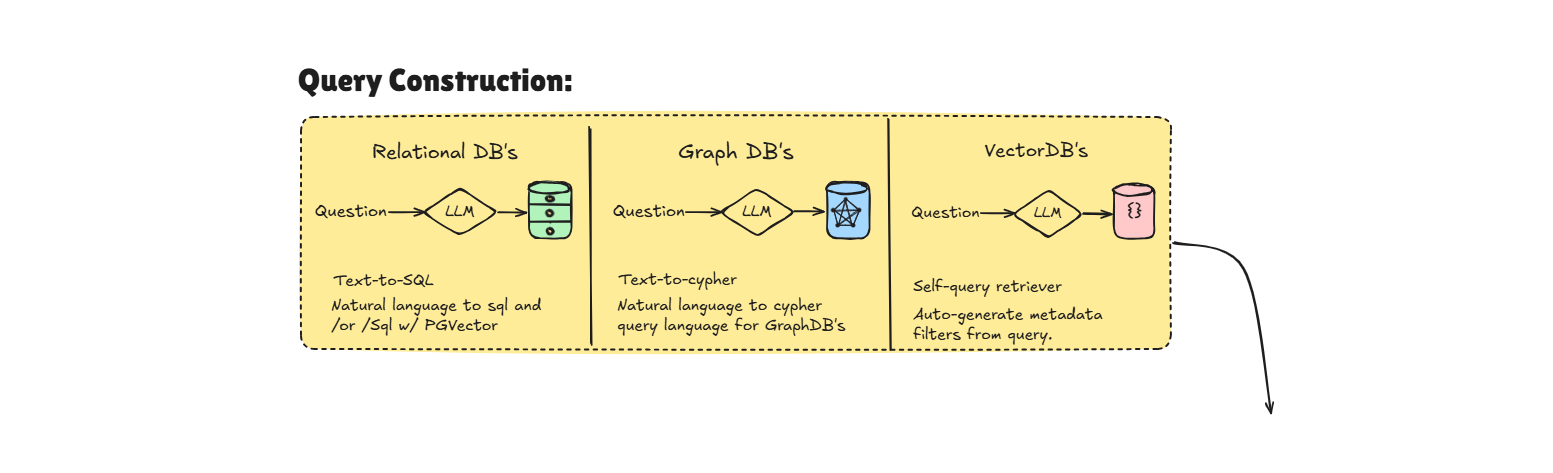

In [4]:
from IPython.display import Image
display(Image("/content/Screenshot 2025-09-06 143056.png"))

For graph and SQL, see helpful resources:<br>
https://blog.langchain.dev/query-construction/

https://blog.langchain.dev/enhancing-rag-based-applications-accuracy-by-constructing-and-leveraging-knowledge-graphs/

##Part 1: Query structuring for matadata filters.<br>
Flow:

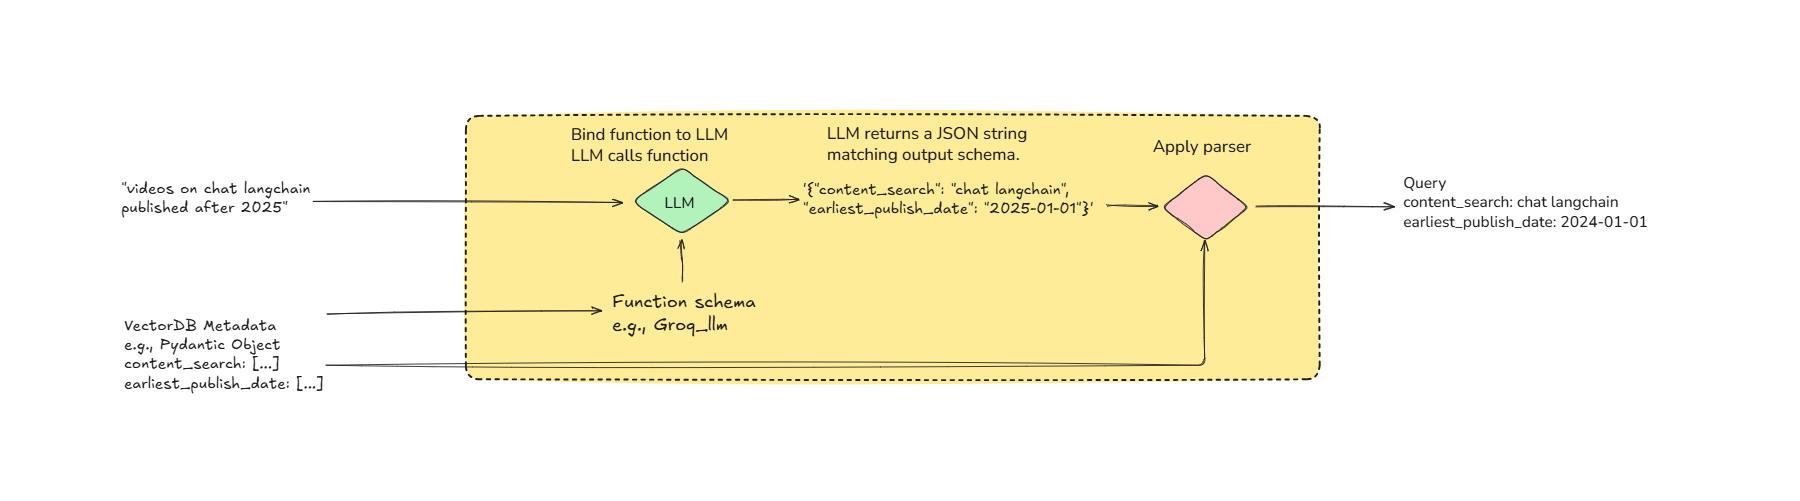

In [5]:
display(Image("/content/Screenshot 2025-09-07 121849.png"))

- Many vectorstores contain metadata fields.<br>
- This makes it possible to filter for specific chunks based on metadata.<br>
- Let's look at some example metadata we might see in database of YouTube transcripts.



In [7]:
import yt_dlp

url = "https://www.youtube.com/watch?v=yezDEWako8U"

# No download, just metadata
ydl_opts = {"quiet": True, "skip_download": True}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info = ydl.extract_info(url, download=False)

# Print all available metadata keys
for key, value in info.items():
    print(f"{key}: {value}")

id: yezDEWako8U
title: Harry Styles - Adore You (Official Video – Extended Version)
formats: [{'format_id': 'sb3', 'format_note': 'storyboard', 'ext': 'mhtml', 'protocol': 'mhtml', 'acodec': 'none', 'vcodec': 'none', 'url': 'https://i.ytimg.com/sb/yezDEWako8U/storyboard3_L0/default.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgj12finBg==&sigh=rs$AOn4CLAYk_3oYv-kuKH0zwqs2vrQklSDjw', 'width': 48, 'height': 27, 'fps': 0.21551724137931033, 'rows': 10, 'columns': 10, 'fragments': [{'url': 'https://i.ytimg.com/sb/yezDEWako8U/storyboard3_L0/default.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgj12finBg==&sigh=rs$AOn4CLAYk_3oYv-kuKH0zwqs2vrQklSDjw', 'duration': 464.0}], 'audio_ext': 'none', 'video_ext': 'none', 'vbr': 0, 'abr': 0, 'tbr': None, 'resolution': '48x27', 'aspect_ratio': 1.78, 'filesize_approx': None, 'http_headers': {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/132.0.0.0 Safari/537.36', 'Accept': 'text/html,application/xhtml+xml,app

In [8]:
import datetime
from typing import Literal, Optional, Tuple
from langchain_core.pydantic_v1 import BaseModel, Field

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [30]:
import datetime
from typing import Optional
from pydantic import BaseModel, Field

class MusicSearch(BaseModel):
    """Search over a database of tutorial videos about a software library."""

    content_search: str = Field(
        ...,
        description="Similarity search query applied to video transcripts."
    )
    title_search: str = Field(
        ...,
        description=(
            "Alternate version of the content search query to apply to video titles. "
            "Should be succinct and only include key words that could be in a video title."
        )
    )
    min_view_count: Optional[int] = Field(
        None,
        description="Minimum view count filter, inclusive. Only use if explicitly specified."
    )
    max_view_count: Optional[int] = Field(
        None,
        description="Maximum view count filter, exclusive. Only use if explicitly specified."
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Earliest publish date filter, inclusive. Only use if explicitly specified."
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Latest publish date filter, exclusive. Only use if explicitly specified."
    )
    min_length_sec: Optional[int] = Field(
        None,
        description="Minimum video length in seconds, inclusive. Only use if explicitly specified."
    )
    max_length_sec: Optional[int] = Field(
        None,
        description="Maximum video length in seconds, exclusive. Only use if explicitly specified."
    )

    def pretty_print(self) -> None:
      for field, model_field in self.__class__.model_fields.items():  # ✅ use class, not instance
          value = getattr(self, field)
          default = getattr(model_field, "default", None)
          if value is not None and value != default:
              print(f"{field}: {value}")

Now, we prompt the LLM to produce queries.

In [31]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq # Corrected import
from google.colab import userdata

system = """You are an expert in converting natural language questions into database queries.
You have access to a database of music videos related to the Harry Styles song "Adore You," specifically for building LLM-powered applications.
Given a user question, generate an optimized database query that retrieves the most relevant results.

If you encounter acronyms or unfamiliar terms, do not attempt to rephrase or alter them."""

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# LLM with function call
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

structured_llm = llm.with_structured_output(MusicSearch)
query_analyzer = prompt | structured_llm

In [22]:
query_analyzer

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert in converting natural language questions into database queries.\nYou have access to a database of music videos related to the Harry Styles song "Adore You," specifically for building LLM-powered applications.\nGiven a user question, generate an optimized database query that retrieves the most relevant results.\n\nIf you encounter acronyms or unfamiliar terms, do not attempt to rephrase or alter them.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='{question}'), additional_kwargs={})])
| RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x7e70dce94620>, async_client=<groq.resources.chat.completions.AsyncCompletio

In [32]:

query_analyzer.invoke({"question": "who sang adore you?"}).pretty_print()

content_search: who sang Adore You Harry Styles
title_search: Adore You Harry Styles


In [33]:
query_analyzer.invoke(
    {"question": "when was adore you released"}
).pretty_print()

content_search: Adore You release date when was released
title_search: Adore You release


In [34]:
query_analyzer.invoke(
    {"question": "All the harry styles songs"}
).pretty_print()

content_search: Harry Styles songs
title_search: Harry Styles


In [37]:
query_analyzer.invoke(
    {
        "question": "harrly styles songs under 5 minutes"
    }
).pretty_print()

content_search: Harry Styles songs
title_search: Harry Styles
max_length_sec: 300


*So far, we have implemented the methodology for constructing a query by filtering the metadata.*